In [1]:
import numpy as np
# import sympy as sp
from plotly import express as px
from matplotlib import pyplot as plt
import pandas as pd
import scipy as scp
import matplotlib.patches as patches
plt.style.use('ggplot')

datos={}
listacositas=list(range(1,5))+['5_ascensor','5_octogono']

columnas=['Dato','a','b','Error a','Error b','ChiCuadrado reducido']
todo=pd.DataFrame(columns=columnas)

In [2]:
def B_short(x,n,a,log=False):
    if log:
        return np.exp(a)*x**n
    else:    
        return a*x**n

In [3]:
def func_rectita(x,a,b):
    return a*x+b

def prom_pesado(valor,error):
    omega= 1/error**2

    ppes=np.sum(valor*(omega))/(np.sum(omega))
    epes=np.sqrt(1/(np.sum(omega)))
    print("promedio pesau:\n $",ppes,"\\pm",epes,"$")
    return np.array([ppes,epes])

In [4]:
for i in listacositas:
    datos[f'{i}']=pd.read_csv(f'V_{i}.csv')
    

datos['1']['d']*=1e-2
datos['2']['d']*=1e-2

In [5]:
Voscoct=pd.concat([datos['1'],datos['2'],datos['5_octogono']],ignore_index=True)
Voscoct=Voscoct.sort_values(by=['d'])
Vin=Voscoct['V'].to_numpy()
din=Voscoct['d'].to_numpy()

In [6]:
def chi_squared(y_real,poly):
    return np.sum(((y_real - poly) ** 2) / y_real)

def chi_squared_reducido(f,x,a,y,s):
    
    print(x.shape)
    print(a.shape)
    print(f(x,*a).shape)
    
    return np.sum(((f(x,*a)-y)/s)**2)      /(len(y)-len(a))

(9,)
(2,)
(9,)
x
d


C:\Users\soysa\AppData\Local\Temp\ipykernel_3692\3193303841.py:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  todo=pd.concat([todo,_temp_df])


(16,)
(2,)
(16,)
x
d
(4,)
(2,)
(4,)
d
(4,)
(2,)
(4,)
d
(8,)
(2,)
(8,)
d
(13,)
(2,)
(13,)
d


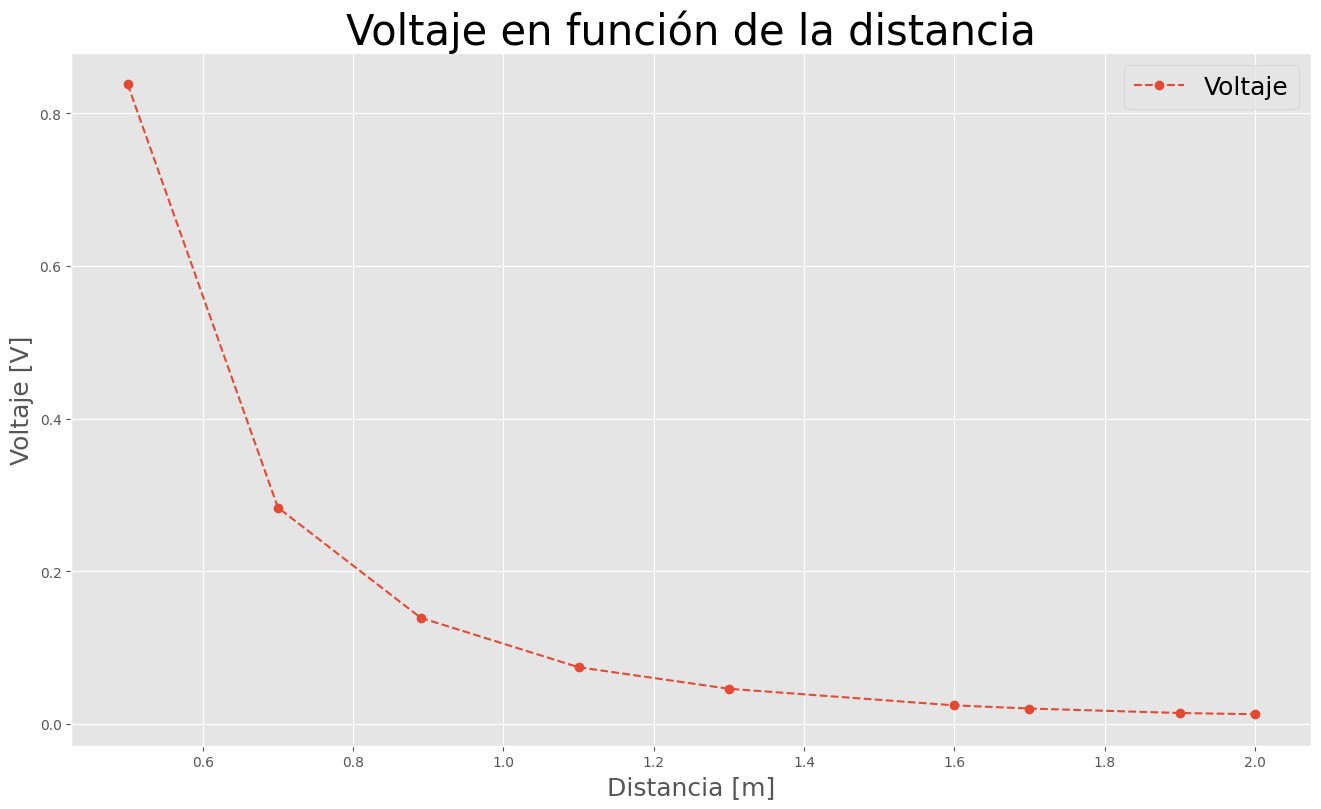

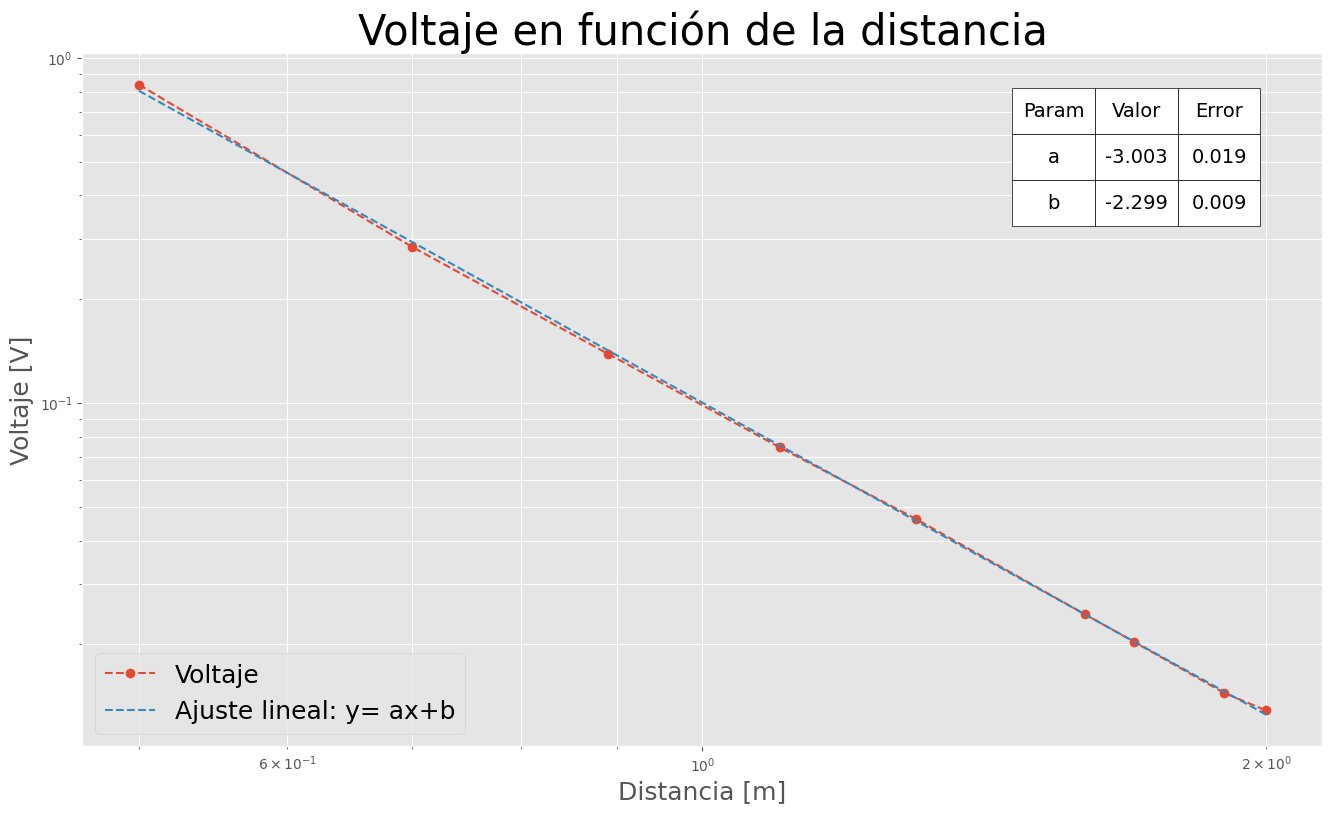

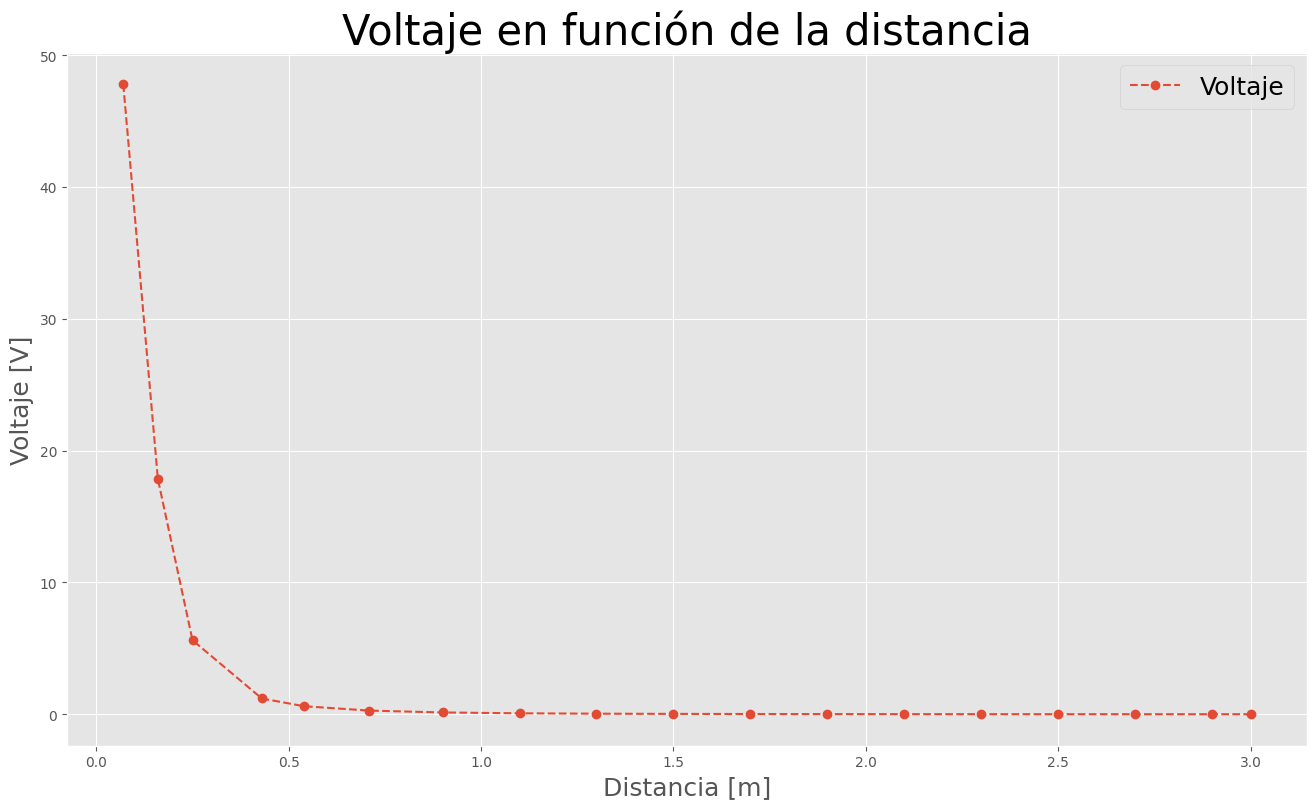

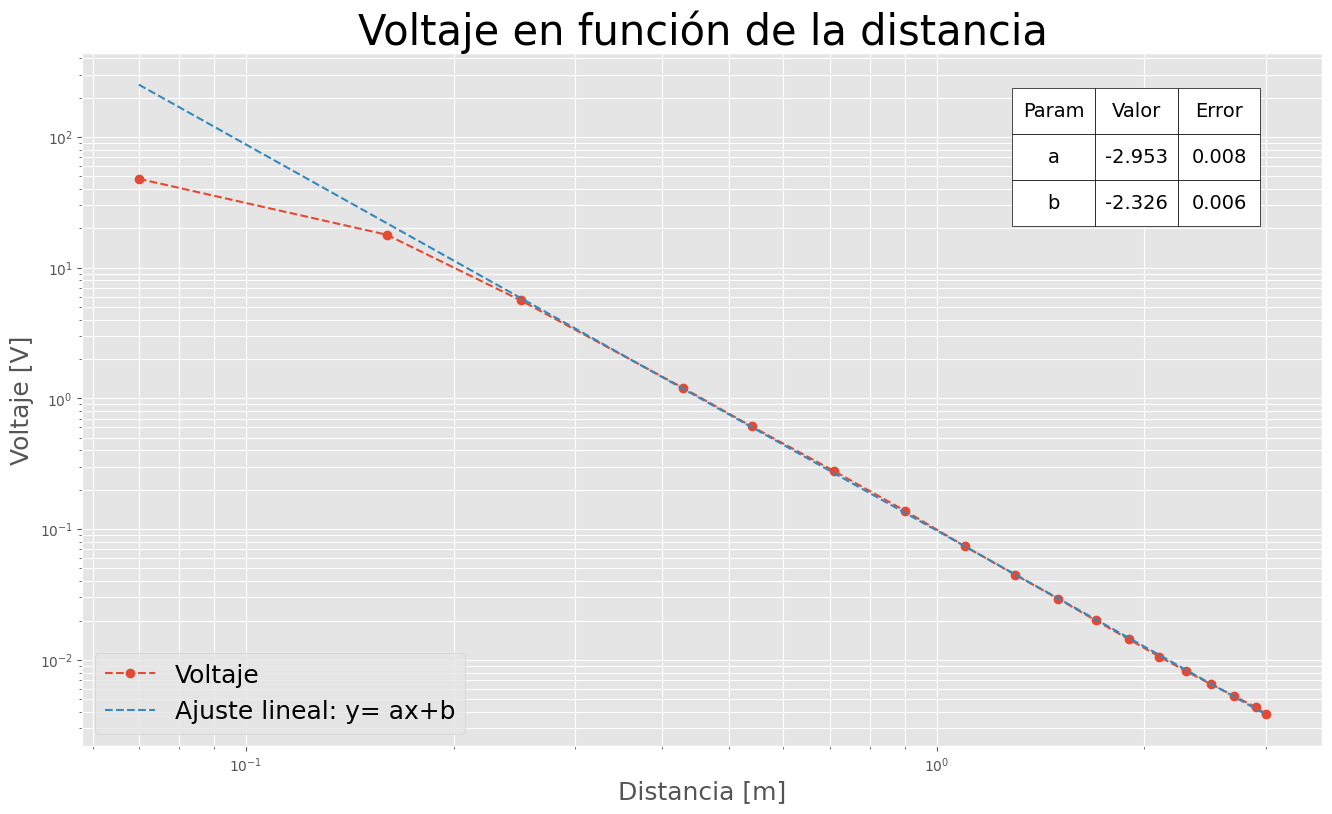

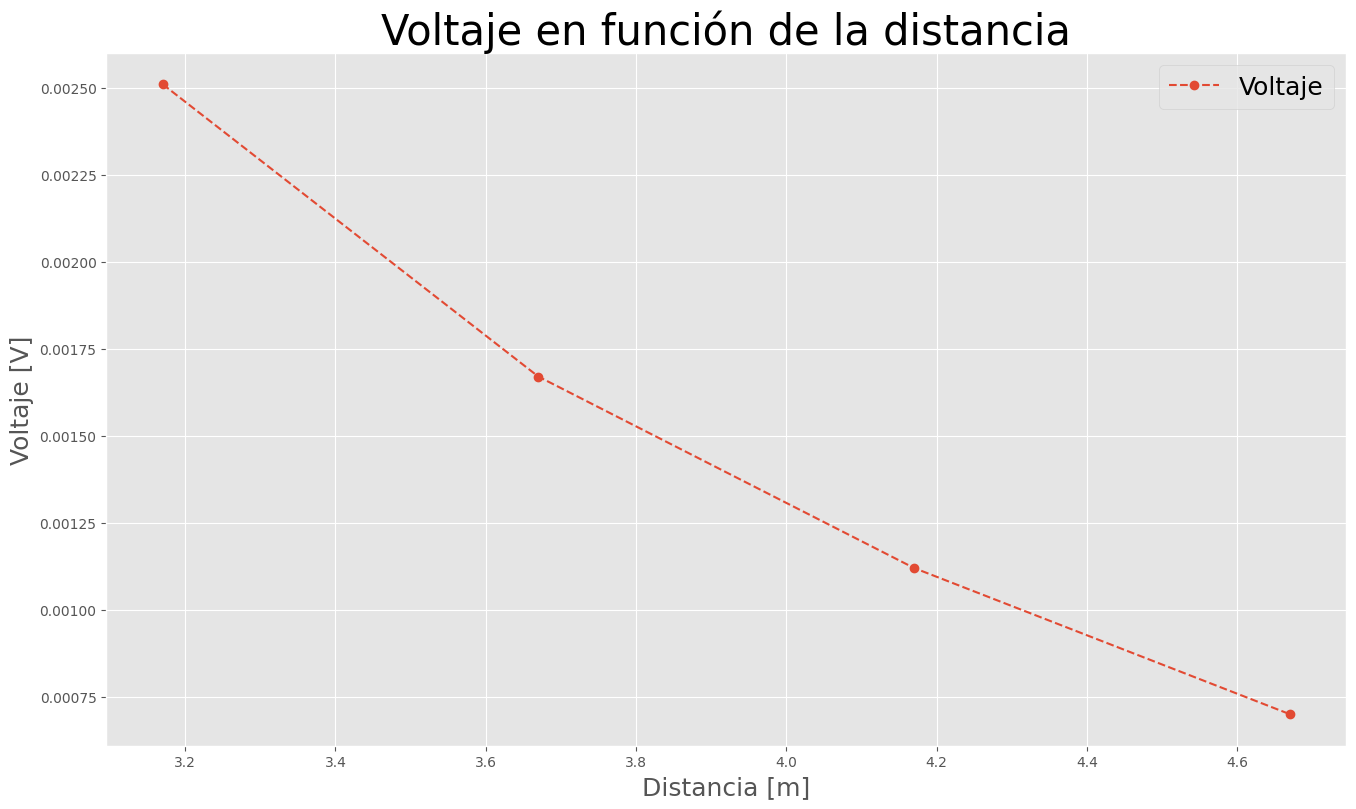

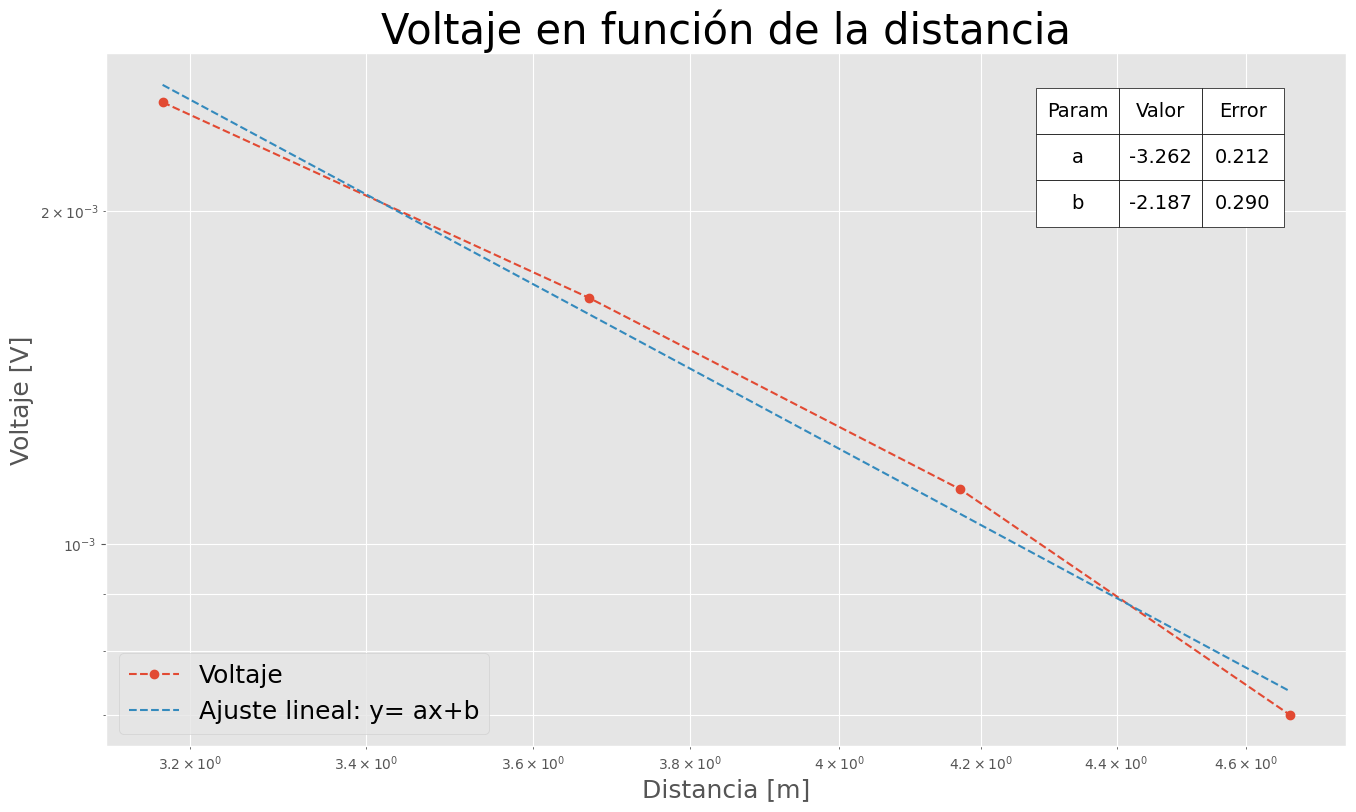

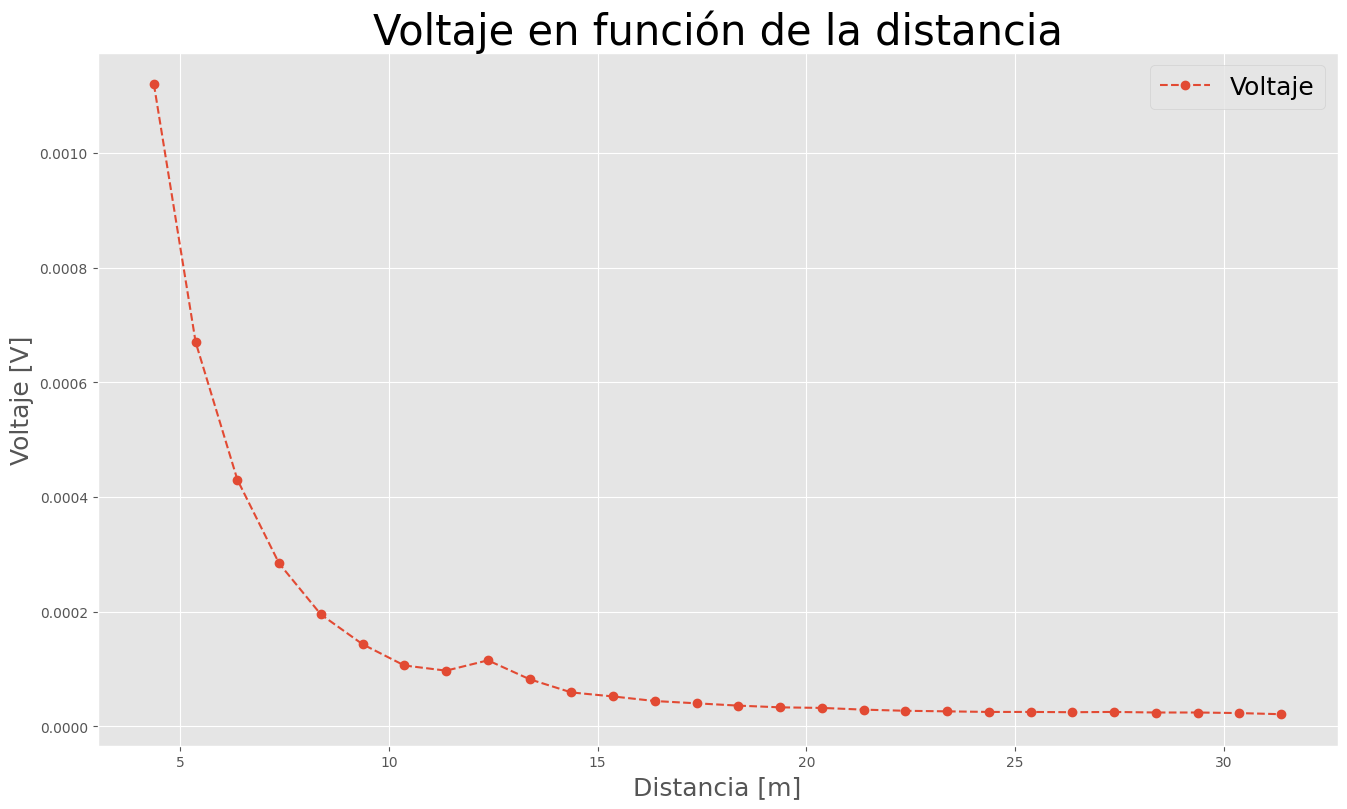

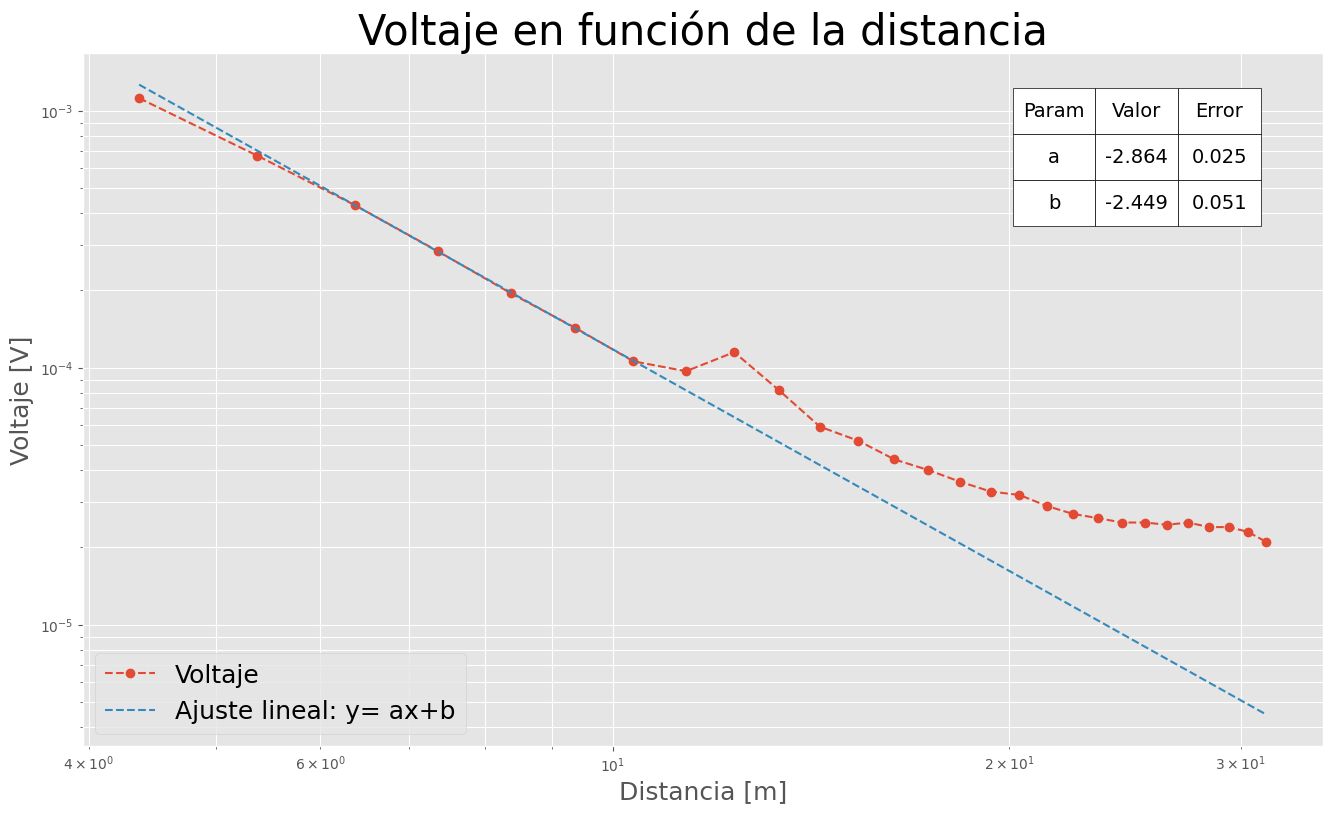

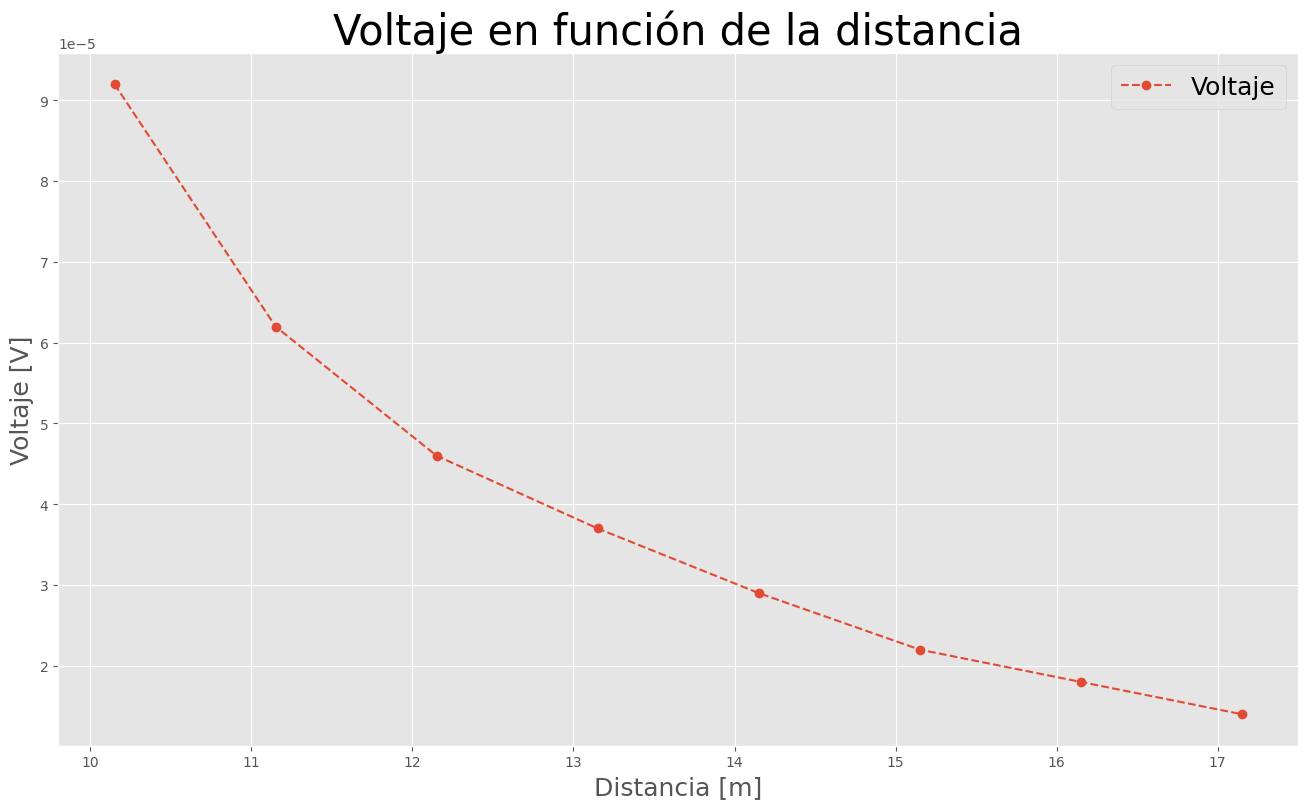

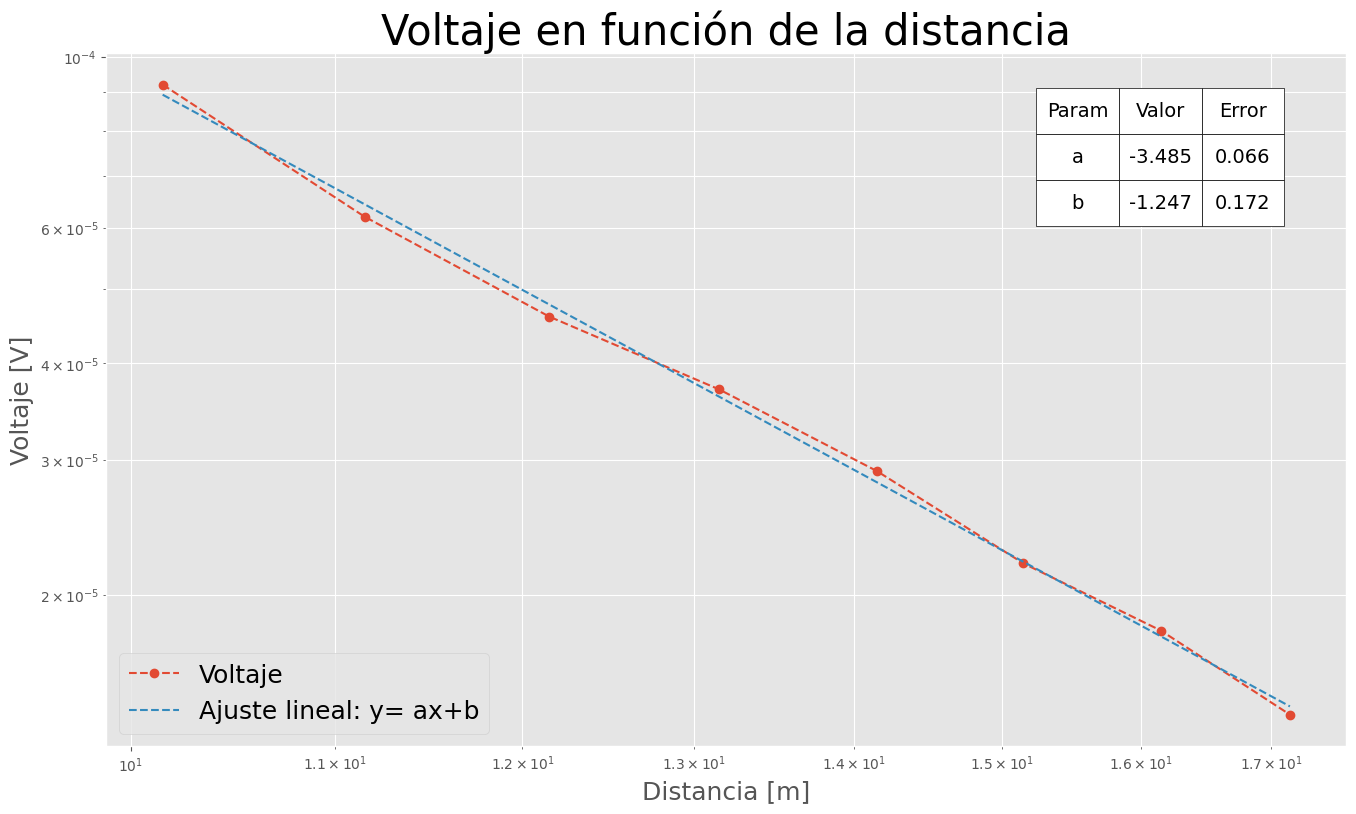

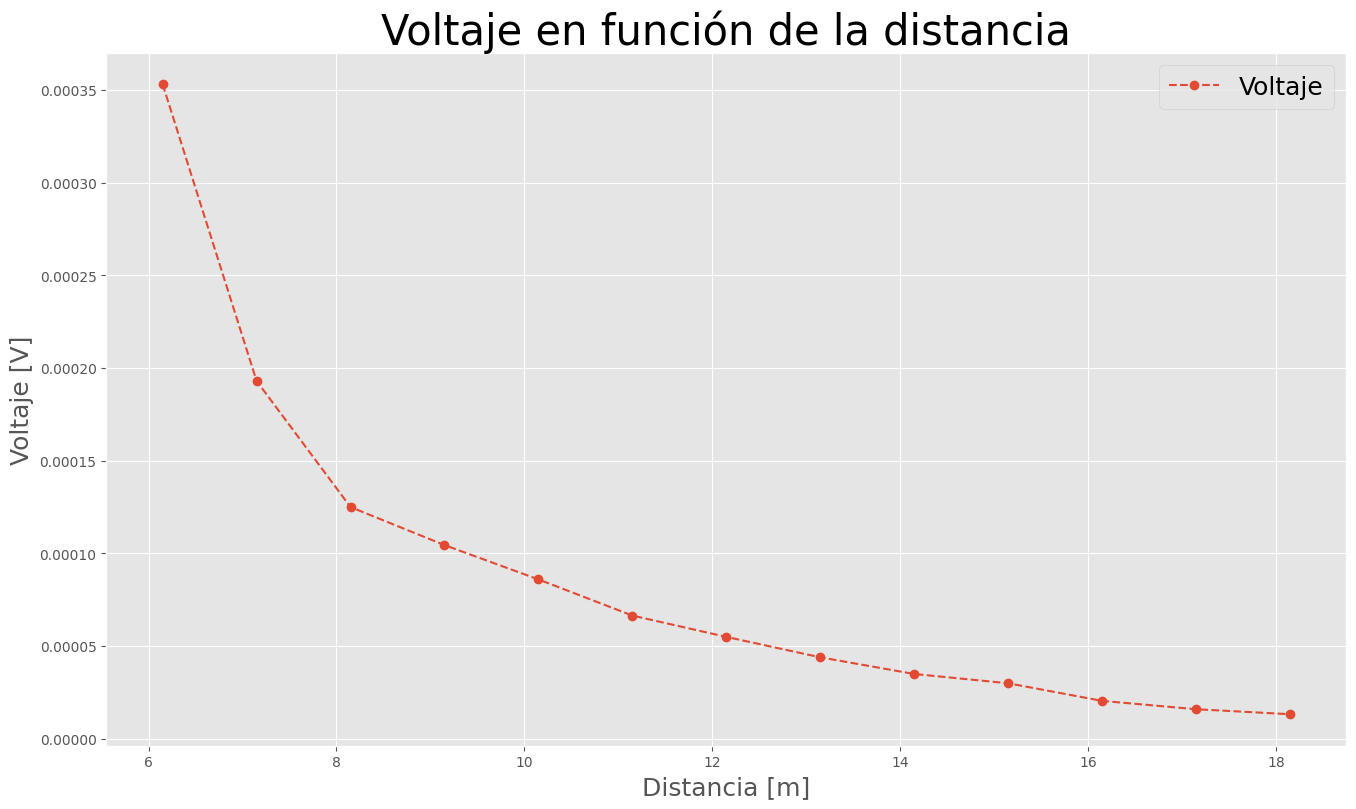

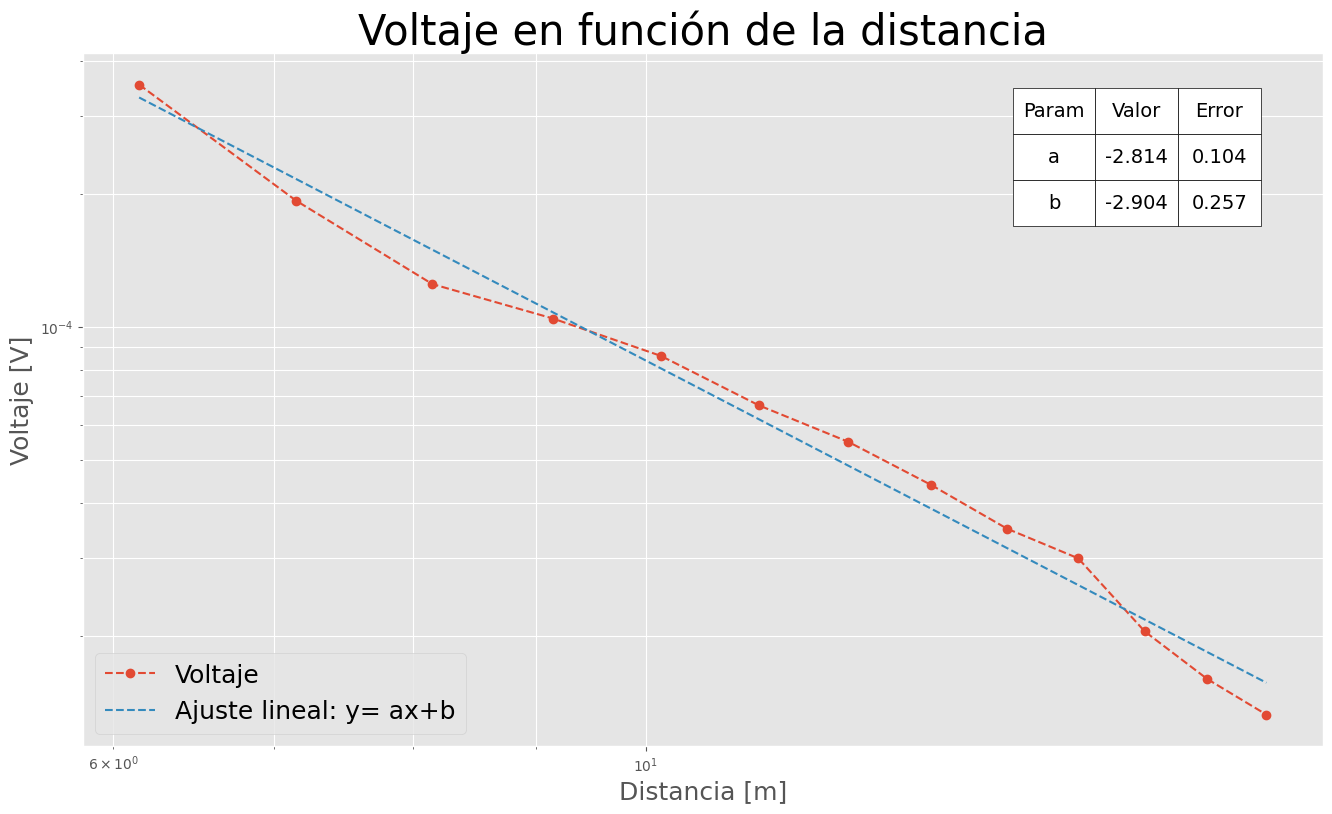

In [7]:
for i in listacositas:
    d,V=datos[f'{i}']['d'],datos[f'{i}']["V"]
    cutinf=0
    cuthigh=len(V)
    if i == 2:
        cutinf=2

    
    if i == 4:
        cutinf=2
        cuthigh=6

    P=np.polyfit(np.log(d[cutinf:cuthigh]),np.log(V[cutinf:cuthigh]),1)

    popt,pcov= scp.optimize.curve_fit(func_rectita,np.log(d[cutinf:cuthigh]),np.log(V[cutinf:cuthigh]),p0=[*P])
    
    perr = np.sqrt(np.diag(pcov))
    
    plt.figure(figsize=(16,9))
    plt.grid(True, which="both")

    plt.plot(d,V,'o--')

    plt.title('Voltaje en función de la distancia',fontsize=30)
    plt.legend(['Voltaje'],fontsize=18)

    plt.xlabel('Distancia [m]',fontsize=18)
    plt.ylabel('Voltaje [V]',fontsize=18)

 
    plt.savefig(f'graficos2/Grafico_{i}.png', bbox_inches='tight', dpi=150)

    # plt.figure(figsize=(16,9))
    # plt.grid(True, which="both")

    # plt.loglog(d,V,'o--')
    # plt.loglog(d,B_short(d,*P,log=True),'--')
        
    # Calculate chi-squared value and format it accordingly
    # chi_val = chi_squared(V[cutinf:cuthigh], B_short(d[cutinf:cuthigh], *P, log=True))
    if i in [1,2]:
        chi_red=chi_squared_reducido(func_rectita,np.log(d[cutinf:cuthigh]),P,np.log(V[cutinf:cuthigh]),0.02)
        print('x')
    else:
        chi_red=chi_squared_reducido(func_rectita,np.log(d[cutinf:cuthigh]),P,np.log(V[cutinf:cuthigh]),20e-6)
    print('d')
    
    _temp_df=pd.DataFrame(columns=columnas,data=[[f'V {i}',*P,*perr,chi_red]])
    
    todo=pd.concat([todo,_temp_df])
    
    # Format parameters: a and b with three decimals, chi-squared in scientific notation with two decimals.
    k = pd.DataFrame({
        'Param': ['a', 'b'],#['a', 'b', 'χ²'],
        'Valor': [f"{P[0]:.3f}", f"{P[1]:.3f}"], #[f"{P[0]:.3f}", f"{P[1]:.3f}", f"{chi_red:.2e}"],
        'Error': [f"{perr[0]:.3f}",f"{perr[1]:.3f}"]
    })
    
    plt.figure(figsize=(16, 9))
    plt.grid(True, which="both")
    plt.loglog(d, V, 'o--')
    plt.loglog(d, B_short(d, *P, log=True), '--')
    
    # Get current axes and add a white rectangle behind the table area
    ax = plt.gca()
    # The bbox values are the same as those used for the table: [left, bottom, width, height] in axis coordinates
    rect = patches.Rectangle((0.75, 0.75), 0.2, 0.2, transform=ax.transAxes,
                             facecolor='white', edgecolor='none', zorder=2)
    ax.add_patch(rect)
    
    # Add table with custom formatting and place it in the upper right corner
    table = plt.table(
        cellText=k.values,
        colLabels=k.columns,
        loc='upper right',
        cellLoc='center',
        bbox=[0.75, 0.75, 0.2, 0.2]  # [left, bottom, width, height] in axis coordinates
    )
    table.auto_set_font_size(False)
    table.set_fontsize(14)
    table.set_zorder(3)  # Ensure the table is above the white rectangle
    
    plt.title('Voltaje en función de la distancia' ,fontsize=30)
    plt.legend(['Voltaje','Ajuste lineal: y= ax+b'],loc='lower left',fontsize=18)

    plt.xlabel('Distancia [m]',fontsize=18)
    plt.ylabel('Voltaje [V]',fontsize=18)
    plt.savefig(f'graficos2/Grafico_{i}_log.png', bbox_inches='tight', dpi=150)


In [8]:
print(todo,'\n')
print('prom \n',np.average(todo['a']))

print('desv est \n',np.std(todo['a']))

prom_pesado(todo['a'],todo['Error a'])
prom_pesado(todo['b'],todo['Error b'])
for j,i in enumerate(["Osciloscopio Día 1", "Osciloscopio Día 2", "Lock-In Día 3", "Lock-In Día 4", "Lock-In Día 5 ascensor", "Lock-In Día 5 octogono"]):
    todo['Dato'].iloc[j]=i

todo[columnas[:-1]].to_latex('tabla.tex',index=False,column_format='c|c|c|c|c',float_format="%.2f")

           Dato         a         b   Error a   Error b  ChiCuadrado reducido
0           V 1 -3.003338 -2.298986  0.018637  0.008990          1.593344e+00
0           V 2 -2.952572 -2.325651  0.008427  0.006490          1.480629e+00
0           V 3 -3.262445 -2.187257  0.212439  0.289645          9.418993e+06
0           V 4 -2.863853 -2.449454  0.024883  0.051205          1.282149e+05
0  V 5_ascensor -3.485126 -1.247135  0.065920  0.171716          2.547753e+06
0  V 5_octogono -2.814423 -2.903758  0.104317  0.257413          3.885114e+07 

prom 
 -3.063626048853077
desv est 
 0.2363510573815595
promedio pesau:
 $ -2.958893413999849 \pm 0.0072702856550791554 $
promedio pesau:
 $ -2.317109934330263 \pm 0.005230031700590462 $


C:\Users\soysa\AppData\Local\Temp\ipykernel_3692\280762847.py:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  todo['Dato'].iloc[j]=i
C:\Users\soysa\AppData\Local\Temp\ipykernel_3692\280762847.py:9: SettingWithCopyWarning: 
A value is trying

(39,)
(2,)
(39,)


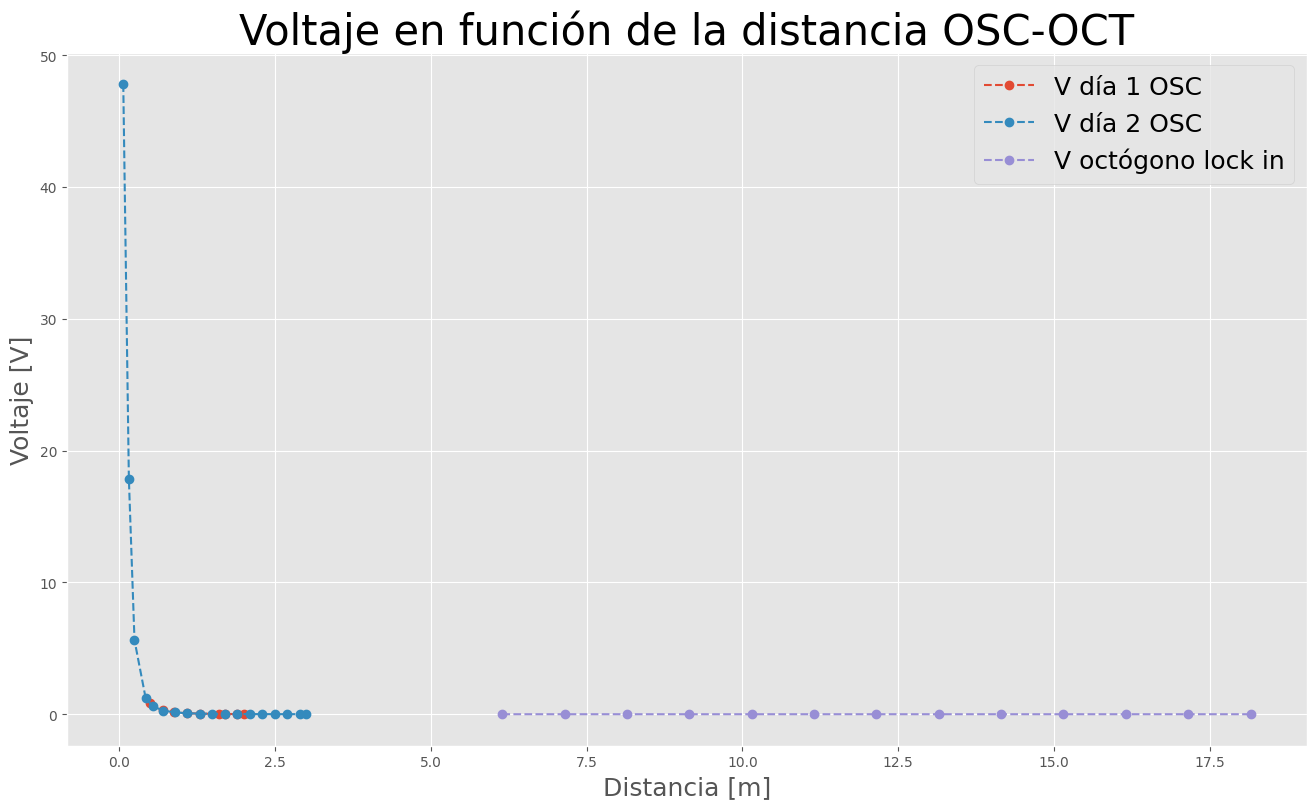

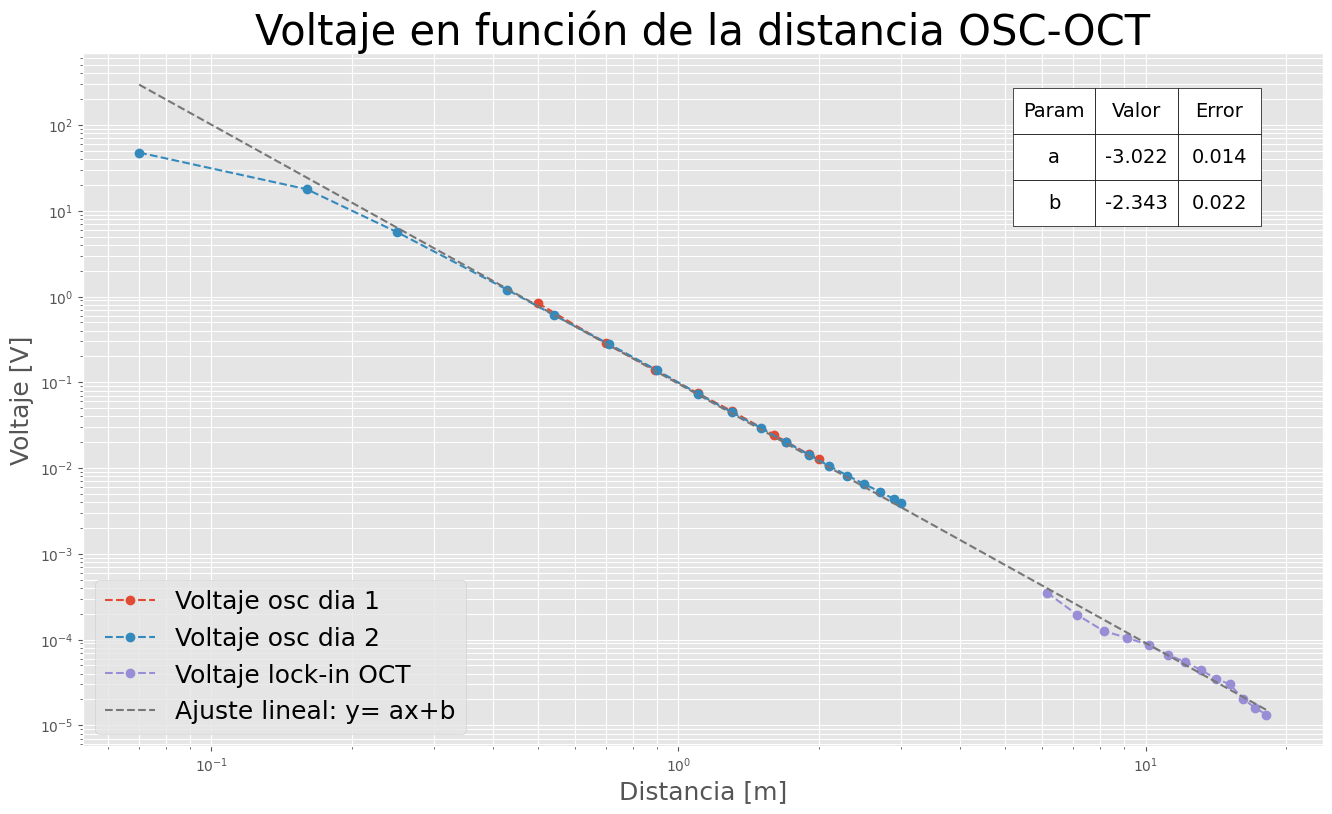

In [15]:
# %%script false

d_ict={}
V_ict={}

for i in range(1):
    
    d,V=Voscoct['d'],Voscoct["V"]
    
    for k,j in enumerate([datos['1'],datos['2'],datos['5_octogono']]):
        d_ict[f'{k}']=j['d']
        V_ict[f'{k}']=j['V']
        
    cutinf=1
    cuthigh=len(V)
    
    if i == 4:
        cutinf=1
        cuthigh=6

    P=np.polyfit(np.log(d[cutinf:cuthigh]),np.log(V[cutinf:cuthigh]),1)

    popt,pcov= scp.optimize.curve_fit(func_rectita,np.log(d[cutinf:cuthigh]),np.log(V[cutinf:cuthigh]),p0=[*P])
    
    perr = np.sqrt(np.diag(pcov))
    
    plt.figure(figsize=(16,9))
    plt.grid(True, which="both")

    for k in range(3):
        plt.plot(d_ict[f'{k}'],V_ict[f'{k}'],'o--')

    plt.title('Voltaje en función de la distancia OSC-OCT',fontsize=30)
    plt.legend(['V día 1 OSC','V día 2 OSC','V octógono lock in'],fontsize=18)

    plt.xlabel('Distancia [m]',fontsize=18)
    plt.ylabel('Voltaje [V]',fontsize=18)

 
    plt.savefig(f'graficos2/Grafico_osc_oct.png', bbox_inches='tight', dpi=300)

 
    # plt.figure(figsize=(16,9))
    # plt.grid(True, which="both")

    # plt.loglog(d,V,'o--')
    # plt.loglog(d,B_short(d,*P,log=True),'--')
        
    # Calculate chi-squared value and format it accordingly
    # chi_val = chi_squared(V[cutinf:cuthigh], B_short(d[cutinf:cuthigh], *P, log=True))
    
    chi_red=chi_squared_reducido(func_rectita,np.log(d[cutinf:cuthigh]),P,np.log(V[cutinf:cuthigh]),0.02)

    
    
    _temp_df=pd.DataFrame(columns=columnas,data=[[f'V {i}',*P,*perr,chi_red]])
    
    todo=pd.concat([todo,_temp_df])
    
    # Format parameters: a and b with three decimals, chi-squared in scientific notation with two decimals.
    k = pd.DataFrame({
        'Param': ['a', 'b'],#['a', 'b', 'χ²'],
        'Valor': [f"{P[0]:.3f}", f"{P[1]:.3f}"], #[f"{P[0]:.3f}", f"{P[1]:.3f}", f"{chi_red:.2e}"],
        'Error': [f"{perr[0]:.3f}",f"{perr[1]:.3f}"]
    })
    
    plt.figure(figsize=(16, 9))
    plt.grid(True, which="both")
    
    for ñ in range(3):
        plt.loglog(d_ict[f'{ñ}'],V_ict[f'{ñ}'],'o--')
    # plt.loglog(d, V, 'o--')
    plt.loglog(d, B_short(d, *P, log=True), '--')
    
    # Get current axes and add a white rectangle behind the table area
    ax = plt.gca()
    # The bbox values are the same as those used for the table: [left, bottom, width, height] in axis coordinates
    rect = patches.Rectangle((0.75, 0.75), 0.2, 0.2, transform=ax.transAxes,
                             facecolor='white', edgecolor='none', zorder=2)
    ax.add_patch(rect)
    
    # Add table with custom formatting and place it in the upper right corner
    table = plt.table(
        cellText=k.values,
        colLabels=k.columns,
        loc='upper right',
        cellLoc='center',
        bbox=[0.75, 0.75, 0.2, 0.2]  # [left, bottom, width, height] in axis coordinates
    )
    table.auto_set_font_size(False)
    table.set_fontsize(14)
    table.set_zorder(3)  # Ensure the table is above the white rectangle
    
    plt.title('Voltaje en función de la distancia OSC-OCT' ,fontsize=30)
    plt.legend(['Voltaje osc dia 1','Voltaje osc dia 2', 'Voltaje lock-in OCT','Ajuste lineal: y= ax+b'],loc='lower left',fontsize=18)

    plt.xlabel('Distancia [m]',fontsize=18)
    plt.ylabel('Voltaje [V]',fontsize=18)
    plt.savefig(f'graficos2/Grafico_osc_oct_log.png', bbox_inches='tight', dpi=300)


In [10]:
%%script false

print(todo,'\n')
print('prom \n',np.average(todo['a']))

print('desv est \n',np.std(todo['a']))

prom_pesado(todo['a'],todo['Error a'])

# todo.to_latex('tabla.tex',index=False)

Couldn't find program: 'false'
